# Import Libraries

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import (f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report)
import seaborn as sns
import gc

mne.set_log_level('WARNING')
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch:", torch.__version__)
print("GPU    :", torch.cuda.is_available())
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
stage_names = ['W', 'N1', 'N2', 'N3', 'REM']
print("Device :", DEVICE)

PyTorch: 2.11.0+cu128
GPU    : True
Device : cuda


# Data Loading

- Load the preprocessed EEG recordings.
- Each file contains sleep epochs that were already segmented and cleaned during preprocessing.

In [ ]:
PROCESSED_DIR = "/content/drive/MyDrive/Queens_notebooks/processed"
CNN_WEIGHTS   = "/content/drive/MyDrive/Queens_notebooks/processed/cnn_final_model.pth"

all_npz  = sorted(glob.glob(os.path.join(PROCESSED_DIR, "*.npz")))
subjects = [{'name': os.path.basename(f).replace('.npz', ''), 'path': f}
            for f in all_npz]

print(f"Total subjects: {len(subjects)}")

# Same 80/20 split as the CNN+BiLSTM notebook
n_test         = int(len(subjects) * 0.2)
test_subjects  = subjects[:n_test]
train_subjects = subjects[n_test:]

print(f"Train: {len(train_subjects)} subjects")
print(f"Test : {len(test_subjects)}  subjects")

Total subjects: 153
Train: 123 subjects
Test : 30  subjects


- The dataset consists of EEG recordings from multiple subjects. Each subject is stored as a separate `.npz` file. An **80/20** subject-level split is used to ensure that unseen subjects are evaluated during testing, providing a realistic estimate of generalization performance.

# ConvBlock and TwoStreamCNN

- The convolutional blocks learn temporal EEG features such as sleep spindles, K-complexes, and other frequency-related patterns. Batch normalization stabilizes training, while dropout helps reduce overfitting.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, pool_size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size,
                      stride=stride, padding=kernel_size // 2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.MaxPool1d(pool_size),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        return self.block(x)

class TwoStreamCNN(nn.Module):
    def __init__(self, n_classes=5, Fs=100):
        super().__init__()
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs // 2,  stride=Fs // 16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs * 4, stride=Fs // 2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        small    = self.cnn_small(x)
        large    = self.cnn_large(x)
        combined = torch.cat([small, large], dim=1)
        return self.classifier(combined)

# CNN + Transformer model

- The model combines CNN feature extraction with Transformer-based sequence modelling. The CNN learns spatial-temporal EEG features from individual epochs, while the Transformer captures long-range dependencies between consecutive sleep epochs.

In [ ]:
class CNNTransformer(nn.Module):
    """
    Same two-stream CNN as DeepSleepNet for epoch-level feature extraction.
    Replaces the BiLSTM with a Transformer encoder for sequence-level modelling.

    Based on the sequence-level Transformer idea from:
    Phan et al., SleepTransformer (IEEE TBME 2022)
    """
    def __init__(self, n_classes=5, Fs=100,
                 d_model=256, nhead=8,
                 num_layers=4, dim_feedforward=1024,
                 dropout=0.1):
        super().__init__()

        # Same CNN streams as DeepSleepNet
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs // 2,  stride=Fs // 16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs * 4, stride=Fs // 2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )

        # CNN output dim = 128 + 128 = 256 = d_model
        assert d_model == 256, "d_model must match CNN output size (256)"

        # Positional encoding
        # Transformers have no built-in sense of order - positional
        # encoding injects position information into the sequence.
        # We use the standard sinusoidal encoding from Vaswani et al. 2017.
        self.pos_dropout = nn.Dropout(dropout)
        max_len          = 200
        pe               = torch.zeros(max_len, d_model)
        position         = torch.arange(0, max_len).unsqueeze(1).float()
        div_term         = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                     # (1, max_len, d_model)
        self.register_buffer('pe', pe)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward= dim_feedforward,
            dropout        = dropout,
            batch_first    = True              # (batch, seq, features)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=num_layers)

        # Classifier
        self.classifier = nn.Linear(d_model, n_classes)
        self.dropout    = nn.Dropout(dropout)

    def extract_cnn_features(self, x):
        """x: (batch, 1, 3000) → (batch, 256)"""
        small    = self.cnn_small(x).squeeze(-1)
        large    = self.cnn_large(x).squeeze(-1)
        return torch.cat([small, large], dim=1)

    def forward(self, x):
        """
        x: (batch, seq_len, 3000)
        Returns: (batch, seq_len, n_classes)
        """
        batch, seq_len, _ = x.shape

        # Extract CNN features for every epoch in the sequence
        cnn_out = torch.stack(
            [self.extract_cnn_features(x[:, t, :].unsqueeze(1))
             for t in range(seq_len)],
            dim=1
        )                                        # (batch, seq_len, 256)

        # Add positional encoding
        cnn_out = cnn_out + self.pe[:, :seq_len, :]
        cnn_out = self.pos_dropout(cnn_out)

        # Transformer encoder — full self-attention over all epochs
        out = self.transformer(cnn_out)          # (batch, seq_len, 256)
        out = self.dropout(out)

        # Classify each epoch
        return self.classifier(out)              # (batch, seq_len, 5)


# check
model     = CNNTransformer()
dummy_seq = torch.zeros(4, 25, 3000)
out       = model(dummy_seq)
print("Output shape    :", out.shape)           # should be (4, 25, 5)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Compare with DeepSleepNet parameter count
class DeepSleepNet(nn.Module):
    def __init__(self, n_classes=5, Fs=100):
        super().__init__()
        self.cnn_small = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs//2,  stride=Fs//16, pool_size=8),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=4),
            ConvBlock(128, 128, kernel_size=8, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.cnn_large = nn.Sequential(
            ConvBlock(1, 128, kernel_size=Fs*4, stride=Fs//2, pool_size=4),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            ConvBlock(128, 128, kernel_size=6, stride=1, pool_size=2),
            nn.AdaptiveMaxPool1d(1)
        )
        self.bilstm1    = nn.LSTM(256,  512, batch_first=True, bidirectional=True)
        self.bilstm2    = nn.LSTM(1024, 512, batch_first=True, bidirectional=True)
        self.dropout    = nn.Dropout(0.5)
        self.shortcut   = nn.Linear(256, 1024)
        self.classifier = nn.Linear(1024, n_classes)

    def extract_cnn_features(self, x):
        small = self.cnn_small(x).squeeze(-1)
        large = self.cnn_large(x).squeeze(-1)
        return torch.cat([small, large], dim=1)

    def forward(self, x):
        batch, seq_len, _ = x.shape
        cnn_out = torch.stack(
            [self.extract_cnn_features(x[:, t, :].unsqueeze(1)) for t in range(seq_len)],
            dim=1
        )
        out, _  = self.bilstm1(cnn_out)
        out      = self.dropout(out)
        out, _  = self.bilstm2(out)
        out      = self.dropout(out)
        out      = out + self.shortcut(cnn_out)
        return self.classifier(out)

dsn = DeepSleepNet()
print(f"DeepSleepNet params: {sum(p.numel() for p in dsn.parameters()):,}")
print(f"CNNTransformer params: {sum(p.numel() for p in model.parameters()):,}")

Output shape    : torch.Size([4, 25, 5])
Total parameters: 3,678,981
DeepSleepNet params: 10,240,517
CNNTransformer params: 3,678,981


# Load CNN pretrained weights

In [ ]:
# Load CNN weights from the best fold of the CNN-only training
pretrained      = torch.load(CNN_WEIGHTS, map_location=DEVICE, weights_only=True)
cnn_weights     = {k: v for k, v in pretrained.items()
                   if k.startswith('cnn_small') or k.startswith('cnn_large')}

print(f"CNN weight tensors to load: {len(cnn_weights)}")
print("Keys:", list(cnn_weights.keys())[:4], "...")

CNN weight tensors to load: 42
Keys: ['cnn_small.0.block.0.weight', 'cnn_small.0.block.0.bias', 'cnn_small.0.block.1.weight', 'cnn_small.0.block.1.bias'] ...


- Transfer learning was applied by initializing the CNN feature extractor with weights from a previously trained CNN model. This reduces training time and improves convergence stability.

# Dataset and sequence builder

- Rather than classifying each epoch independently, the model learns contextual information from neighboring epochs, which better reflects the sequential nature of sleep architecture.

In [ ]:
class SeqSleepDataset(Dataset):
    """Dataset for sequences of epochs."""
    def __init__(self, X_seq, y_seq):
        self.X = X_seq.astype(np.float32)
        self.y = y_seq.astype(np.int64)
        # Normalize each epoch to zero mean and unit variance
        mean = self.X.mean(axis=-1, keepdims=True)
        std  = self.X.std(axis=-1,  keepdims=True) + 1e-8
        self.X = (self.X - mean) / std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.LongTensor(self.y[idx])


SEQ_LEN = 25

def make_sequences(epochs, labels, seq_len=25):
    """Slice a subject's recording into non-overlapping windows."""
    X_seqs, y_seqs = [], []
    n = len(labels)
    for start in range(0, n - seq_len + 1, seq_len):
        X_seqs.append(epochs[start : start + seq_len])
        y_seqs.append(labels[start : start + seq_len])
    return np.array(X_seqs), np.array(y_seqs)


# Trial: use 40 training subjects to avoid crash
# Change to train_subjects for the final run
TRIAL_SUBJECTS = train_subjects[:40]

# Build training sequences
X_seq_list, y_seq_list = [], []
for s in TRIAL_SUBJECTS:
    d = np.load(s['path'])
    Xs, ys = make_sequences(d['epochs'], d['labels'], SEQ_LEN)
    X_seq_list.append(Xs)
    y_seq_list.append(ys)
    d.close()

X_train_seq = np.concatenate(X_seq_list)
y_train_seq = np.concatenate(y_seq_list)

# Build test sequences
X_test_list, y_test_list = [], []
for s in test_subjects:
    d = np.load(s['path'])
    Xs, ys = make_sequences(d['epochs'], d['labels'], SEQ_LEN)
    X_test_list.append(Xs)
    y_test_list.append(ys)
    d.close()

X_test_seq = np.concatenate(X_test_list)
y_test_seq = np.concatenate(y_test_list)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test  sequences: {X_test_seq.shape}")

Train sequences: (1966, 25, 3000)
Test  sequences: (1228, 25, 3000)


#  K-Fold CV

- Five-fold cross-validation is used to evaluate the robustness of the model. In each fold, a different validation subset was used while the remaining data are used for training. This reduces the likelihood that the reported performance is biased by a particular train-validation split.


Fold 1/5 | 1572 train seqs | 394 val seqs
  Epoch 10/30 | Train Loss: 0.4680  Acc: 81.9% | Val Loss: 0.8002  Acc: 72.5%
  Epoch 20/30 | Train Loss: 0.4378  Acc: 83.2% | Val Loss: 0.5167  Acc: 81.6%
  Epoch 30/30 | Train Loss: 0.3997  Acc: 84.3% | Val Loss: 0.4531  Acc: 82.9%

FOLD 1 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 82.88%
  Macro F1  : 76.86%
  Cohen's κ : 0.7603

              precision    recall  f1-score   support

           W       0.93      0.90      0.92      2783
          N1       0.42      0.44      0.43       830
          N2       0.83      0.89      0.86      3960
          N3       0.88      0.77      0.82       675
         REM       0.86      0.77      0.81      1602

    accuracy                           0.83      9850
   macro avg       0.78      0.76      0.77      9850
weighted avg       0.83      0.83      0.83      9850



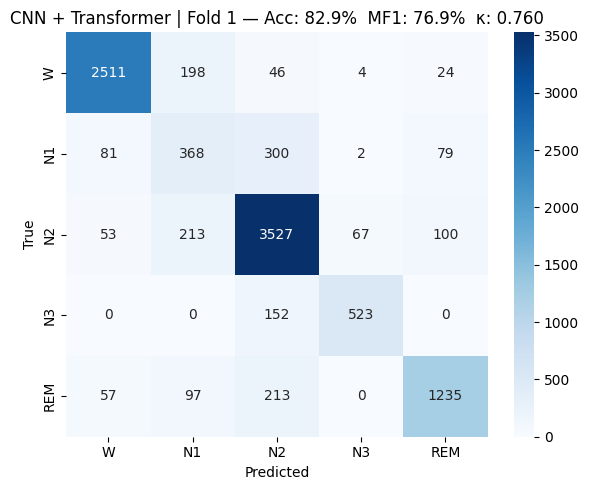

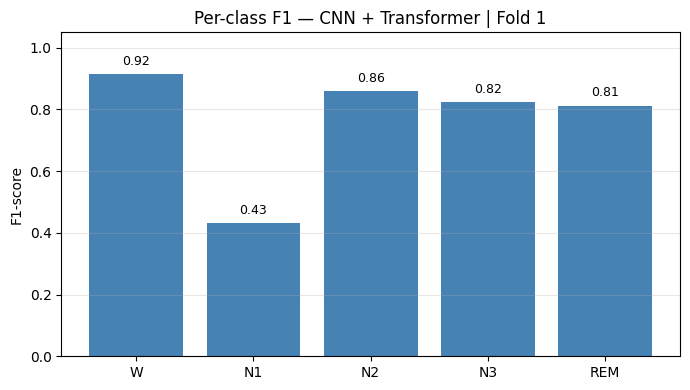


Fold 2/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4631  Acc: 82.4% | Val Loss: 0.6359  Acc: 75.8%
  Epoch 20/30 | Train Loss: 0.4100  Acc: 84.2% | Val Loss: 0.5999  Acc: 78.7%
  Epoch 30/30 | Train Loss: 0.3902  Acc: 84.8% | Val Loss: 0.4827  Acc: 80.9%

FOLD 2 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 80.95%
  Macro F1  : 74.69%
  Cohen's κ : 0.7340

              precision    recall  f1-score   support

           W       0.89      0.91      0.90      2732
          N1       0.49      0.37      0.42      1005
          N2       0.82      0.87      0.85      3960
          N3       0.79      0.82      0.80       756
         REM       0.79      0.75      0.77      1372

    accuracy                           0.81      9825
   macro avg       0.76      0.74      0.75      9825
weighted avg       0.80      0.81      0.80      9825



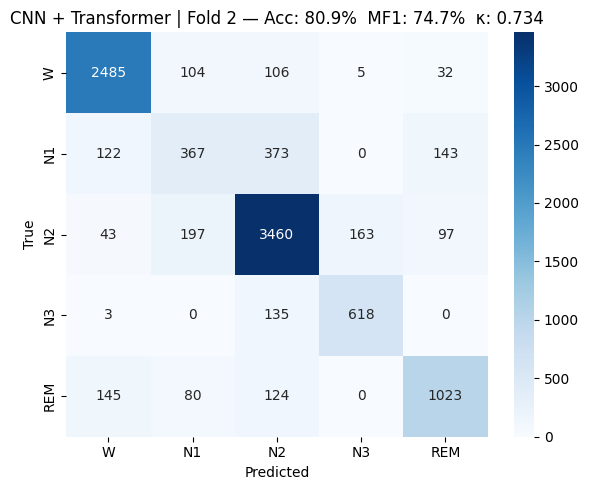

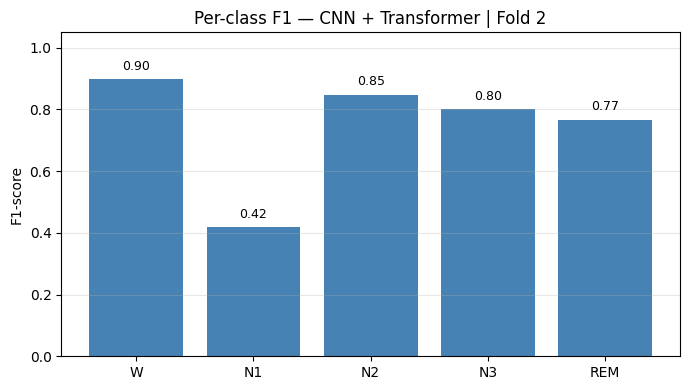


Fold 3/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4725  Acc: 81.8% | Val Loss: 0.3740  Acc: 85.4%
  Epoch 20/30 | Train Loss: 0.4430  Acc: 82.5% | Val Loss: 0.3987  Acc: 84.7%
  Epoch 30/30 | Train Loss: 0.4132  Acc: 83.9% | Val Loss: 0.3852  Acc: 85.0%

FOLD 3 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 85.03%
  Macro F1  : 74.48%
  Cohen's κ : 0.7901

              precision    recall  f1-score   support

           W       0.92      0.96      0.94      3267
          N1       0.71      0.19      0.30       799
          N2       0.84      0.88      0.86      3597
          N3       0.68      0.86      0.76       734
         REM       0.85      0.89      0.87      1428

    accuracy                           0.85      9825
   macro avg       0.80      0.76      0.74      9825
weighted avg       0.84      0.85      0.83      9825



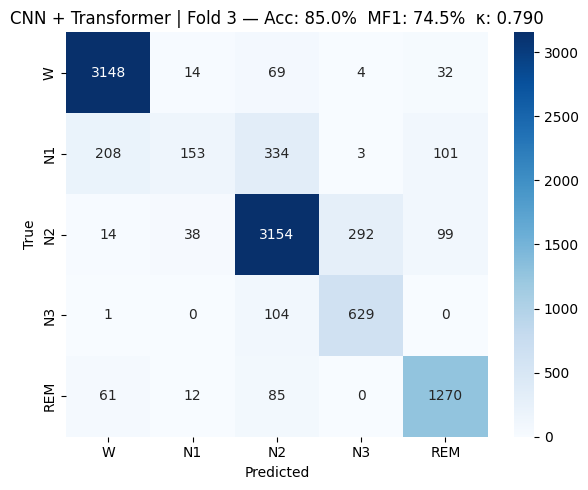

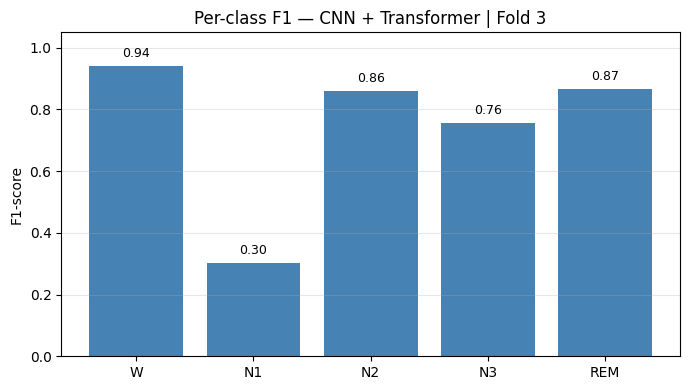


Fold 4/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4727  Acc: 81.7% | Val Loss: 0.4541  Acc: 82.1%
  Epoch 20/30 | Train Loss: 0.4166  Acc: 83.7% | Val Loss: 0.4959  Acc: 81.2%
  Epoch 30/30 | Train Loss: 0.4137  Acc: 84.2% | Val Loss: 0.4399  Acc: 83.0%

FOLD 4 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 83.03%
  Macro F1  : 76.45%
  Cohen's κ : 0.7692

              precision    recall  f1-score   support

           W       0.96      0.91      0.93      2885
          N1       0.58      0.26      0.35      1047
          N2       0.78      0.88      0.83      3488
          N3       0.75      0.93      0.83       828
         REM       0.85      0.90      0.87      1577

    accuracy                           0.83      9825
   macro avg       0.78      0.78      0.76      9825
weighted avg       0.82      0.83      0.82      9825



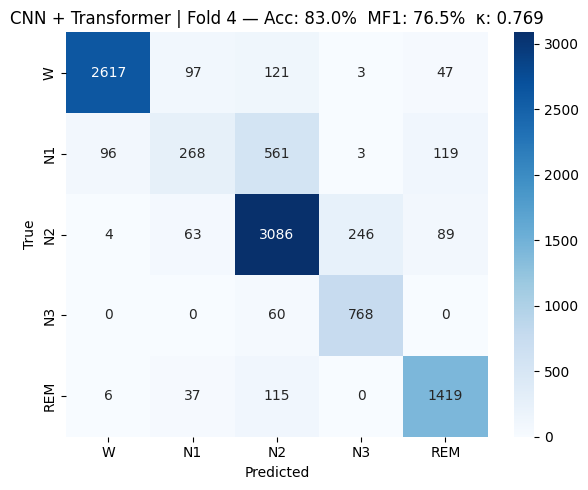

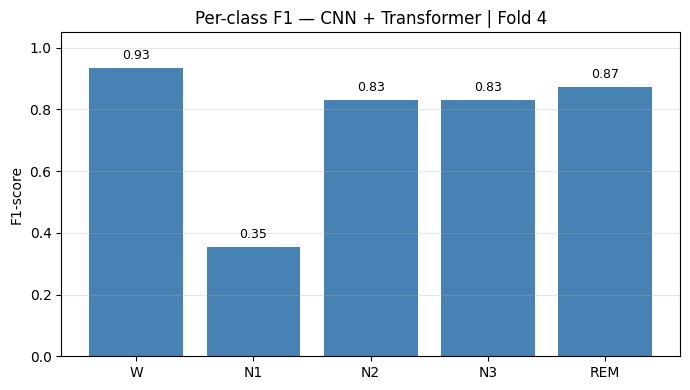


Fold 5/5 | 1573 train seqs | 393 val seqs
  Epoch 10/30 | Train Loss: 0.4840  Acc: 81.5% | Val Loss: 0.5550  Acc: 78.6%
  Epoch 20/30 | Train Loss: 0.4317  Acc: 83.1% | Val Loss: 0.4313  Acc: 84.0%
  Epoch 30/30 | Train Loss: 0.4176  Acc: 84.0% | Val Loss: 0.5239  Acc: 79.2%

FOLD 5 — Validation Metrics  (CNN + Transformer)
  Accuracy  : 79.19%
  Macro F1  : 69.02%
  Cohen's κ : 0.7143

              precision    recall  f1-score   support

           W       0.92      0.96      0.94      3294
          N1       0.55      0.24      0.33       795
          N2       0.82      0.72      0.76      3654
          N3       0.39      1.00      0.56       571
         REM       0.89      0.82      0.85      1511

    accuracy                           0.79      9825
   macro avg       0.71      0.75      0.69      9825
weighted avg       0.82      0.79      0.79      9825



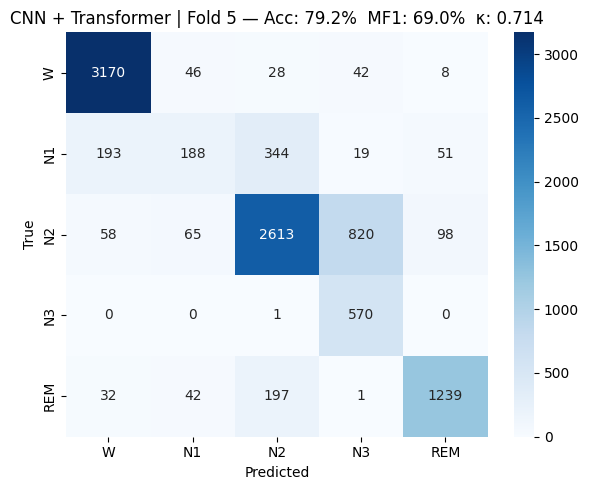

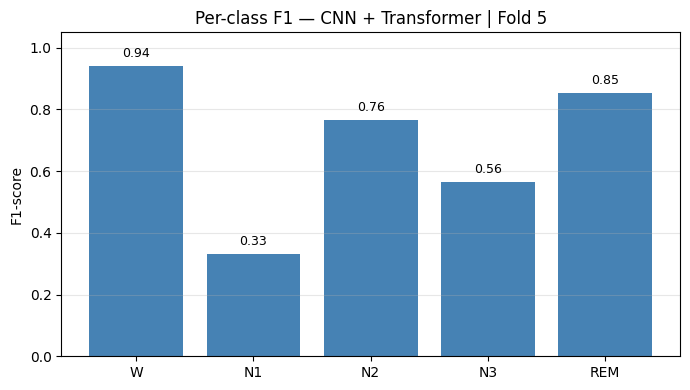

In [ ]:
N_FOLDS  = 5
N_EPOCHS = 30

kf              = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results    = []
fold_histories  = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(range(len(X_train_seq))), 1):

    print(f"\n{'='*55}")
    print(f"Fold {fold}/{N_FOLDS} | {len(tr_idx)} train seqs | {len(val_idx)} val seqs")
    print(f"{'='*55}")

    tr_dataset  = SeqSleepDataset(X_train_seq[tr_idx],  y_train_seq[tr_idx])
    val_dataset = SeqSleepDataset(X_train_seq[val_idx], y_train_seq[val_idx])

    tr_loader  = DataLoader(tr_dataset,  batch_size=16, shuffle=True,  pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

    fold_model = CNNTransformer().to(DEVICE)
    model_dict = fold_model.state_dict()
    model_dict.update(cnn_weights)
    fold_model.load_state_dict(model_dict)

    cnn_params   = (list(fold_model.cnn_small.parameters()) +
                    list(fold_model.cnn_large.parameters()))
    trans_params = (list(fold_model.transformer.parameters()) +
                    list(fold_model.classifier.parameters())  +
                    list(fold_model.pos_dropout.parameters()))

    optimizer = torch.optim.Adam([
        {'params': cnn_params,   'lr': 1e-6},
        {'params': trans_params, 'lr': 1e-4},
    ])
    criterion = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, N_EPOCHS + 1):

        # Train 
        fold_model.train()
        tr_loss, correct, total = 0.0, 0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out      = fold_model(X_b)
            out_flat = out.view(-1, 5)
            y_flat   = y_b.view(-1)
            loss     = criterion(out_flat, y_flat)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
            optimizer.step()
            tr_loss += loss.item()
            correct += (out_flat.argmax(1) == y_flat).sum().item()
            total   += len(y_flat)

        train_loss = tr_loss / len(tr_loader)
        train_acc  = 100 * correct / total

        # Validate 
        fold_model.eval()
        val_loss_total      = 0.0
        all_preds, all_true = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out       = fold_model(X_b)
                out_flat  = out.view(-1, 5)
                y_flat    = y_b.view(-1)
                val_loss_total += criterion(out_flat, y_flat).item()
                all_preds.extend(out_flat.argmax(1).cpu().numpy())
                all_true.extend(y_flat.cpu().numpy())

        val_loss = val_loss_total / len(val_loader)
        val_acc  = 100 * np.mean(np.array(all_preds) == np.array(all_true))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:2d}/{N_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.1f}% | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.1f}%")

    # Fold metrics 
    all_preds    = np.array(all_preds)
    all_true     = np.array(all_true)
    acc          = 100 * (all_preds == all_true).mean()
    mf1          = f1_score(all_true, all_preds, average='macro') * 100
    kappa        = cohen_kappa_score(all_true, all_preds)
    f1_per_class = f1_score(all_true, all_preds, average=None, labels=list(range(5)))
    cm           = confusion_matrix(all_true, all_preds)

    # Print fold metrics 
    print(f"\n{'='*60}")
    print(f"FOLD {fold} — Validation Metrics  (CNN + Transformer)")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Macro F1  : {mf1:.2f}%")
    print(f"  Cohen's κ : {kappa:.4f}")
    print()
    print(classification_report(all_true, all_preds, target_names=stage_names))

    # Fold confusion matrix 
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=stage_names, yticklabels=stage_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"CNN + Transformer | Fold {fold} — "
              f"Acc: {acc:.1f}%  MF1: {mf1:.1f}%  κ: {kappa:.3f}")
    plt.tight_layout()
    plt.show()

    # Fold per-class F1 
    plt.figure(figsize=(7, 4))
    bars = plt.bar(stage_names, f1_per_class, color='steelblue')
    plt.ylabel('F1-score'); plt.ylim(0, 1.05)
    plt.title(f'Per-class F1 — CNN + Transformer | Fold {fold}')
    plt.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, f1_per_class):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Save fold model 
    fold_path = os.path.join(PROCESSED_DIR, f"transformer_fold_{fold}.pth")
    torch.save(fold_model.state_dict(), fold_path)

    fold_results.append({
        'fold'        : fold,
        'acc'         : acc,
        'mf1'         : mf1,
        'kappa'       : kappa,
        'f1_per_class': f1_per_class,
        'cm'          : cm,
        'model_path'  : fold_path,
        'state_dict'  : fold_model.state_dict(),
    })
    fold_histories.append(history)

    del tr_dataset, val_dataset, fold_model, tr_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()

### CV Summary + Loss Plots


5-Fold CV Summary — CNN + Transformer
Fold          Acc      MF1        κ
--------------------------------------
  1        82.88%   76.86%   0.7603
  2        80.95%   74.69%   0.7340
  3        85.03%   74.48%   0.7901
  4        83.03%   76.45%   0.7692
  5        79.19%   69.02%   0.7143
--------------------------------------
  Mean     82.22%   74.30%   0.7536
  Std       1.99%    2.80%   0.0266

  Representative fold (closest to mean MF1): Fold 3  (MF1: 74.48%  |  Mean: 74.30%)


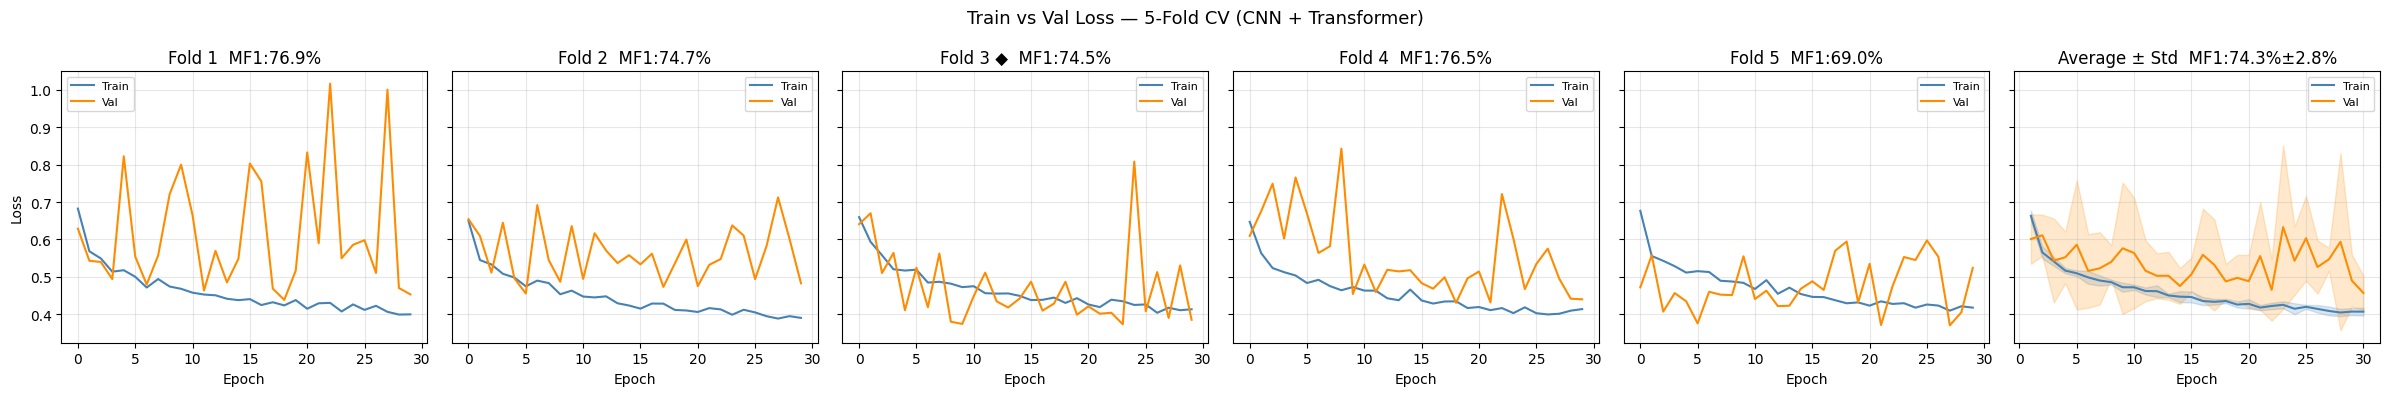

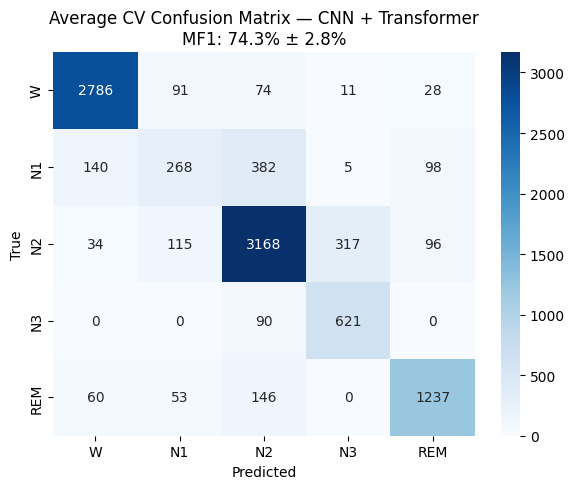

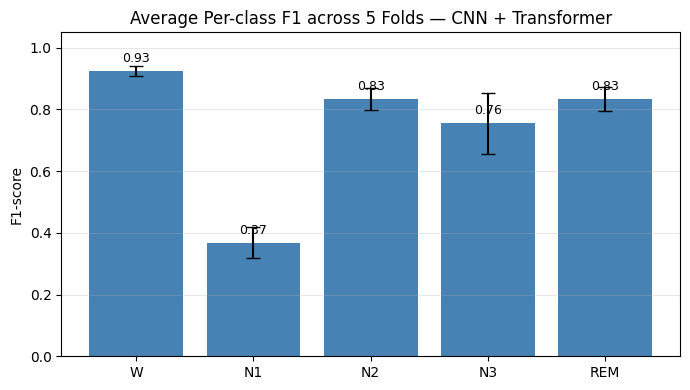

In [ ]:
print(f"\n{'='*50}")
print("5-Fold CV Summary — CNN + Transformer")
print(f"{'='*50}")
print(f"{'Fold':<8} {'Acc':>8} {'MF1':>8} {'κ':>8}")
print("-" * 38)
for r in fold_results:
    print(f"  {r['fold']:<6} {r['acc']:>7.2f}% {r['mf1']:>7.2f}% {r['kappa']:>8.4f}")
print("-" * 38)
accs     = [r['acc']   for r in fold_results]
mf1s     = [r['mf1']   for r in fold_results]
kappas   = [r['kappa'] for r in fold_results]
mean_mf1 = np.mean(mf1s)
print(f"  {'Mean':<6} {np.mean(accs):>7.2f}% {mean_mf1:>7.2f}% {np.mean(kappas):>8.4f}")
print(f"  {'Std':<6} {np.std(accs):>7.2f}% {np.std(mf1s):>7.2f}% {np.std(kappas):>8.4f}")

# Select representative fold (closest to mean MF1) 
avg_fold_idx   = int(np.argmin([abs(m - mean_mf1) for m in mf1s]))
best_trans_fold = fold_results[avg_fold_idx]['fold']
print(f"\n  Representative fold (closest to mean MF1): "
      f"Fold {best_trans_fold}  "
      f"(MF1: {mf1s[avg_fold_idx]:.2f}%  |  Mean: {mean_mf1:.2f}%)")

# Per-fold loss curves + average panel 
n_plots = N_FOLDS + 1
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)

for i, (ax, h) in enumerate(zip(axes[:N_FOLDS], fold_histories)):
    ax.plot(h['train_loss'], label='Train', color='steelblue')
    ax.plot(h['val_loss'],   label='Val',   color='darkorange')
    marker = ' ◆' if i + 1 == best_trans_fold else ''
    ax.set_title(f'Fold {i+1}{marker}  MF1:{fold_results[i]["mf1"]:.1f}%')
    ax.set_xlabel('Epoch')
    if i == 0:
        ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

ax_avg       = axes[-1]
train_matrix = np.array([h['train_loss'] for h in fold_histories])
val_matrix   = np.array([h['val_loss']   for h in fold_histories])
epochs_range = np.arange(1, N_EPOCHS + 1)

for matrix, color, label in [
    (train_matrix, 'steelblue',  'Train'),
    (val_matrix,   'darkorange', 'Val'),
]:
    mean_ = matrix.mean(axis=0)
    std_  = matrix.std(axis=0)
    ax_avg.plot(epochs_range, mean_, color=color, label=label)
    ax_avg.fill_between(epochs_range, mean_ - std_, mean_ + std_,
                        alpha=0.2, color=color)

ax_avg.set_title(f'Average ± Std  MF1:{mean_mf1:.1f}%±{np.std(mf1s):.1f}%')
ax_avg.set_xlabel('Epoch')
ax_avg.legend(fontsize=8)
ax_avg.grid(alpha=0.3)

fig.suptitle('Train vs Val Loss — 5-Fold CV (CNN + Transformer)', fontsize=13)
plt.tight_layout()
plt.show()

# Average confusion matrix across folds 
avg_cm = np.mean([r['cm'] for r in fold_results], axis=0).astype(int)
plt.figure(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Average CV Confusion Matrix — CNN + Transformer\n"
          f"MF1: {mean_mf1:.1f}% ± {np.std(mf1s):.1f}%")
plt.tight_layout()
plt.show()

# Average per-class F1 with error bars 
avg_f1_pc = np.mean([r['f1_per_class'] for r in fold_results], axis=0)
std_f1_pc = np.std( [r['f1_per_class'] for r in fold_results], axis=0)

plt.figure(figsize=(7, 4))
bars = plt.bar(stage_names, avg_f1_pc, color='steelblue',
               yerr=std_f1_pc, capsize=5)
plt.ylabel('F1-score'); plt.ylim(0, 1.05)
plt.title('Average Per-class F1 across 5 Folds — CNN + Transformer')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_f1_pc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Average Weights → Retrain on All Training Data

Averaging weights across all 5 fold models...
Averaged weights loaded ✓

Retraining on full training data (1,966 sequences)...
  Epoch  1/10 | Loss: 0.6286 | Acc: 77.7%
  Epoch  2/10 | Loss: 0.5138 | Acc: 80.9%
  Epoch  3/10 | Loss: 0.5083 | Acc: 80.8%
  Epoch  4/10 | Loss: 0.4746 | Acc: 82.0%
  Epoch  5/10 | Loss: 0.4688 | Acc: 82.4%
  Epoch  6/10 | Loss: 0.4560 | Acc: 82.6%
  Epoch  7/10 | Loss: 0.4633 | Acc: 82.4%
  Epoch  8/10 | Loss: 0.4436 | Acc: 83.0%
  Epoch  9/10 | Loss: 0.4329 | Acc: 83.5%
  Epoch 10/10 | Loss: 0.4330 | Acc: 83.5%

Final model saved → transformer_final_model.pth


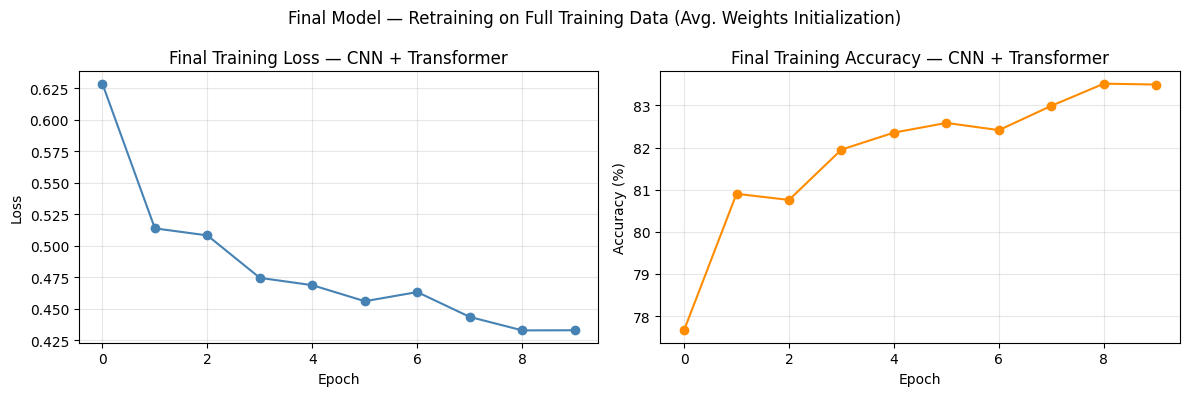


Evaluating on full training data (sanity check)...

Training Set Results — Final CNN + Transformer Model
Accuracy  : 84.27%
Macro F1  : 78.28%
Cohen's κ : 0.7836

              precision    recall  f1-score   support

           W       0.95      0.93      0.94     14961
          N1       0.50      0.48      0.49      4476
          N2       0.87      0.86      0.86     18659
          N3       0.91      0.69      0.79      3564
         REM       0.77      0.92      0.84      7490

    accuracy                           0.84     49150
   macro avg       0.80      0.78      0.78     49150
weighted avg       0.85      0.84      0.84     49150



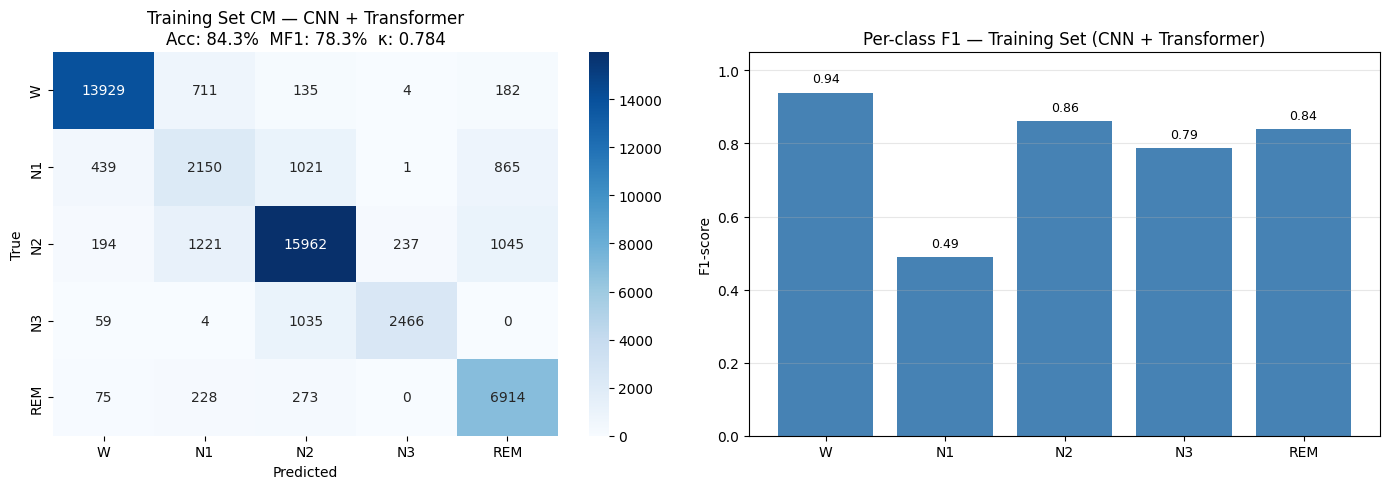

In [ ]:
# Step 1: Average weights across all 5 fold models 
print("Averaging weights across all 5 fold models...")
avg_state = {}
for key in fold_results[0]['state_dict'].keys():
    avg_state[key] = torch.stack(
        [fold_results[i]['state_dict'][key].float() for i in range(N_FOLDS)]
    ).mean(dim=0)

final_trans_model = CNNTransformer().to(DEVICE)
final_trans_model.load_state_dict(avg_state)
print("Averaged weights loaded ✓")

# Step 2: Retrain on ALL training sequences 
print(f"\nRetraining on full training data ({len(X_train_seq):,} sequences)...")

full_seq_dataset = SeqSleepDataset(X_train_seq, y_train_seq)
full_seq_loader  = DataLoader(full_seq_dataset, batch_size=16,
                               shuffle=True, pin_memory=True)

cnn_params_f   = (list(final_trans_model.cnn_small.parameters()) +
                  list(final_trans_model.cnn_large.parameters()))
trans_params_f = (list(final_trans_model.transformer.parameters()) +
                  list(final_trans_model.classifier.parameters())  +
                  list(final_trans_model.pos_dropout.parameters()))

optimizer_final = torch.optim.Adam([
    {'params': cnn_params_f,   'lr': 1e-6},
    {'params': trans_params_f, 'lr': 1e-4},
])
criterion      = nn.CrossEntropyLoss()
N_FINAL_EPOCHS = 10
final_history  = {'train_loss': [], 'train_acc': []}

for epoch in range(1, N_FINAL_EPOCHS + 1):
    final_trans_model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_b, y_b in full_seq_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_final.zero_grad()
        out      = final_trans_model(X_b)
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        loss     = criterion(out_flat, y_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_trans_model.parameters(), max_norm=1.0)
        optimizer_final.step()
        total_loss += loss.item()
        correct    += (out_flat.argmax(1) == y_flat).sum().item()
        total      += len(y_flat)

    train_loss = total_loss / len(full_seq_loader)
    train_acc  = 100 * correct / total
    final_history['train_loss'].append(train_loss)
    final_history['train_acc'].append(train_acc)
    print(f"  Epoch {epoch:2d}/{N_FINAL_EPOCHS} | "
          f"Loss: {train_loss:.4f} | Acc: {train_acc:.1f}%")

final_trans_model_path = os.path.join(PROCESSED_DIR, "transformer_final_model.pth")
torch.save(final_trans_model.state_dict(), final_trans_model_path)
print(f"\nFinal model saved → transformer_final_model.pth")

# Step 3: Final training curve 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(final_history['train_loss'], color='steelblue', marker='o')
ax1.set_title('Final Training Loss - CNN + Transformer')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(final_history['train_acc'], color='darkorange', marker='o')
ax2.set_title('Final Training Accuracy - CNN + Transformer')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(alpha=0.3)

fig.suptitle('Final Model — Retraining on Full Training Data '
             '(Avg. Weights Initialization)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 4: Training set evaluation 
print("\nEvaluating on full training data (sanity check)...")
final_trans_model.eval()
tr_preds, tr_true = [], []
with torch.no_grad():
    for X_b, y_b in full_seq_loader:
        out      = final_trans_model(X_b.to(DEVICE))
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        tr_preds.extend(out_flat.argmax(1).cpu().numpy())
        tr_true.extend(y_flat.cpu().numpy())

tr_pred = np.array(tr_preds)
tr_true = np.array(tr_true)

tr_acc   = 100 * (tr_pred == tr_true).mean()
tr_mf1   = f1_score(tr_true, tr_pred, average='macro') * 100
tr_kappa = cohen_kappa_score(tr_true, tr_pred)
tr_f1_pc = f1_score(tr_true, tr_pred, average=None, labels=list(range(5)))
tr_cm    = confusion_matrix(tr_true, tr_pred)

print(f"\nTraining Set Results - Final CNN + Transformer Model")
print(f"{'='*50}")
print(f"Accuracy  : {tr_acc:.2f}%")
print(f"Macro F1  : {tr_mf1:.2f}%")
print(f"Cohen's κ : {tr_kappa:.4f}")
print()
print(classification_report(tr_true, tr_pred, target_names=stage_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(tr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_title(f"Training Set CM - CNN + Transformer\n"
              f"Acc: {tr_acc:.1f}%  MF1: {tr_mf1:.1f}%  κ: {tr_kappa:.3f}")

bars = ax2.bar(stage_names, tr_f1_pc, color='steelblue')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1 - Training Set (CNN + Transformer)')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, tr_f1_pc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Test Evaluation

Final CNN + Transformer model loaded for test evaluation ✓
Test sequences: 1,228

Test Results — Final CNN + Transformer Model
Accuracy  : 84.03%
Macro F1  : 78.30%
Cohen's κ : 0.7778

              precision    recall  f1-score   support

           W       0.90      0.87      0.88      5138
          N1       0.48      0.41      0.44      2225
          N2       0.87      0.88      0.87     13494
          N3       0.94      0.82      0.88      4152
         REM       0.78      0.91      0.84      5691

    accuracy                           0.84     30700
   macro avg       0.79      0.78      0.78     30700
weighted avg       0.84      0.84      0.84     30700



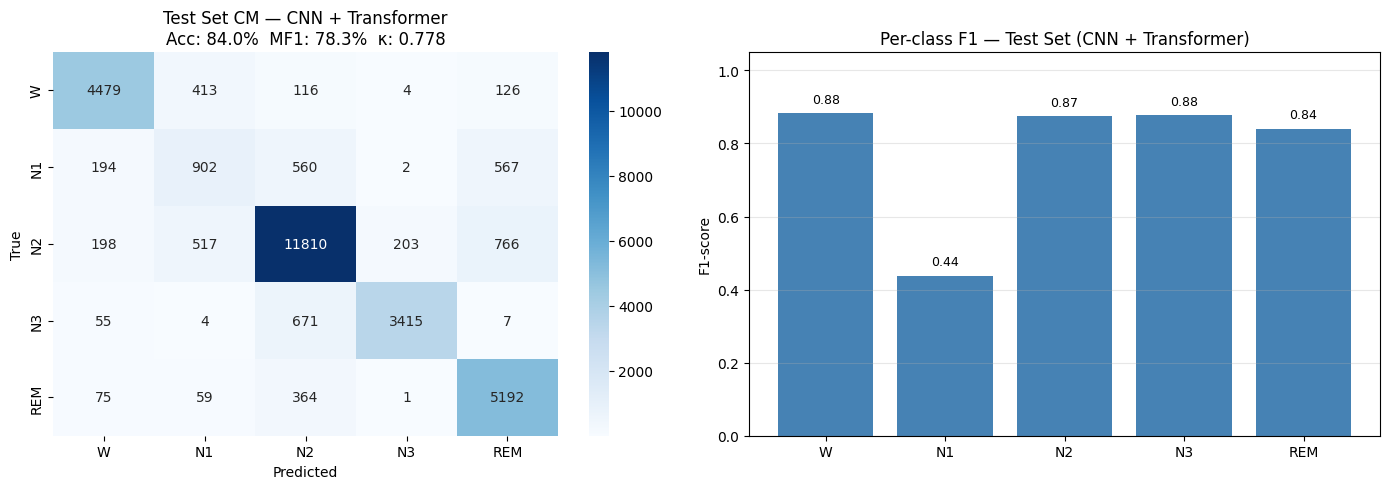

In [ ]:
final_trans_model.load_state_dict(
    torch.load(final_trans_model_path, map_location=DEVICE, weights_only=True)
)
final_trans_model.eval()
print("Final CNN + Transformer model loaded for test evaluation ✓")

test_seq_dataset = SeqSleepDataset(X_test_seq, y_test_seq)
test_seq_loader  = DataLoader(test_seq_dataset, batch_size=32,
                               shuffle=False, pin_memory=True)
print(f"Test sequences: {len(test_seq_dataset):,}")

all_preds, all_true = [], []
with torch.no_grad():
    for X_b, y_b in test_seq_loader:
        out      = final_trans_model(X_b.to(DEVICE))
        out_flat = out.view(-1, 5)
        y_flat   = y_b.view(-1)
        all_preds.extend(out_flat.argmax(1).cpu().numpy())
        all_true.extend(y_flat.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_true)

acc          = 100 * (y_pred == y_true).mean()
mf1          = f1_score(y_true, y_pred, average='macro') * 100
kappa        = cohen_kappa_score(y_true, y_pred)
f1_per_class = f1_score(y_true, y_pred, average=None, labels=list(range(5)))
cm           = confusion_matrix(y_true, y_pred)

print(f"\nTest Results — Final CNN + Transformer Model")
print(f"{'='*50}")
print(f"Accuracy  : {acc:.2f}%")
print(f"Macro F1  : {mf1:.2f}%")
print(f"Cohen's κ : {kappa:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=stage_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
ax1.set_title(f"Test Set CM — CNN + Transformer\n"
              f"Acc: {acc:.1f}%  MF1: {mf1:.1f}%  κ: {kappa:.3f}")

bars = ax2.bar(stage_names, f1_per_class, color='steelblue')
ax2.set_ylabel('F1-score'); ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1 — Test Set (CNN + Transformer)')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1_per_class):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()